In [57]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
from typing import List, Optional
import pandas as pd
import pyarrow as pya
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import glob
from itertools import chain
import numpy as np
from collections import deque, defaultdict
from typing import Dict, List, Optional, Tuple
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
import os, urllib.parse, urllib.request
import codecs
from sklearn import metrics
from scipy import interpolate

In [58]:
all_pathname = r"C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategyV2\New_strategy\X-CANIDS\raw"
all_files = [
    f for f in os.listdir(all_pathname)
    #if f.startswith("dump6-fuzz-") and f.endswith(".parquet")
]

all_ids = [f.split('-')[-1].removesuffix('.parquet') for f in all_files]

print(f"Found {len(all_ids)} fuzzing files.")
print("Fuzzing IDs in discovery order:", all_ids)

Found 39 fuzzing files.
Fuzzing IDs in discovery order: ['120', '240', '360', '479.99999', '044h', '080h', '081h', '111h', '112h', '113h', '162h', '18Fh', '200h', '220h', '251h', '260h', '2B0h', '316h', '329h', '381h', '383h', '386h', '387h', '47Fh', '4F1h', '50Ch', '52Ah', '541h', '545h', '547h', '549h', '553h', '555h', '556h', '557h', '58Bh', '593h', '5A0h', '5B0h']


In [59]:

def hex_to_bytes(h):
    #Convert hex/bytes/string to bytes.
    if h is None or (isinstance(h, float) and np.isnan(h)): 
        return b""
    if isinstance(h, (bytes, bytearray)): 
        return bytes(h)
    s = str(h).strip().replace("0x","").replace(" ","")
    if s == "": 
        return b""
    if len(s) % 2 == 1: 
        s = "0"+s
    try: 
        return bytes.fromhex(s)
    except Exception: 
        print(f"Warning: invalid hex input: {h}")
        return str(h).encode("utf-8", errors="ignore")


def hamming_distance(a: bytes, b: bytes) -> int:
    
    
    len_mismatch = (len(a) != len(b))

    # Pad to same length
    max_len = max(len(a), len(b))
    a_padded = a + b'\x00' * (max_len - len(a))
    b_padded = b + b'\x00' * (max_len - len(b))
    
    # Count differences
    #dist = sum(byte_a != byte_b for byte_a, byte_b in zip(a_padded, b_padded))
    
    distance = 0
    for byte_a, byte_b in zip(a_padded, b_padded):
        distance += bin(byte_a ^ byte_b).count('1')
    return (distance)
    
    #return (dist, len_mismatch)

In [60]:

def compute_hamming_distances_training(dumps, out_csv, process_per_dump=True):
    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    
    records = []
    prev_payload = {}  # {arbitration_id: previous_bytes}
    
    for dump_name, df in dumps:
        d = df.copy()
        
        if "timestamp" not in d.columns:
            if d.index.name == "timestamp":
                d = d.reset_index()
            else:
                d = d.reset_index().rename(columns={"index": "timestamp"})
        
        
        d = d.sort_values("timestamp", kind="mergesort")
        has_label = "label" in d.columns
        
        for _, row in d.iterrows():
            aid = row["arbitration_id"]
            ts = row["timestamp"]
            lab = int(row["label"]) if has_label and not pd.isna(row["label"]) else 0
            curr_bytes = hex_to_bytes(row["data"])
            
            # Get previous payload for this ID
            prev = prev_payload.get(aid)
            
            if prev is not None:
                # Compute Hamming distance
                dist = hamming_distance(curr_bytes, prev)
                #max_len = max(len(curr_bytes), len(prev))
                #norm_dist = dist / (max_len * 8) if max_len > 0 else 0.0
                
                records.append({
                    "dump": dump_name,
                    "timestamp": ts,
                    "arbitration_id": aid,
                    "payload_len": len(curr_bytes),
                    "ham_dist": dist,
                    #"ham_norm": norm_dist,
                    #"len_mismatch": len_mismatch,  
                    "label": lab
                })
            
            

            # Update previous payload
            prev_payload[aid] = curr_bytes
        #False for the bening so we can compute the distances using all 7 dumps
        if process_per_dump:
            prev_payload.clear()
    
    out_df = pd.DataFrame.from_records(records)
    out_df.to_csv(out_csv, index=False)
    print(f" Saved: {out_csv} (rows={len(out_df):,})")
    
    return out_df

In [ ]:
def compute_hamming_distances_testing(row, prev_payload: Dict, ranges_indexed):
    
    aid = row.arbitration_id
    lab = int(row.label) if hasattr(row, 'label') and pd.notna(row.label) else 0
    data = row.data
    curr_bytes = hex_to_bytes(data)
    
    # Get previous payload for this ID
    prev = prev_payload.get(aid)
    
    if prev is not None:
        # Compute Hamming distance
        dist = hamming_distance(curr_bytes, prev)
        #should_update = False
        
        prev_payload[aid] = curr_bytes
        #ASK PROFESSOR - what to do if the previous payload is malicious because you compare a valid one with a malicious that you saved in the payload_prev and you get a FP????
        return dist, lab, prev_payload
    # Always update
    """else:
        # First message for this ID - store it
        prev_payload[aid] = curr_bytes
        return None, lab, prev_payload"""
        # Update previous payload
    prev_payload[aid] = curr_bytes
    return None, lab, prev_payload

In [ ]:
def classify_detection_context(df):
   
    # 1. Determine if the PREVIOUS packet for this ID was an attack
    # We group by ID and shift the label column down by 1
    df['prev_label'] = df.groupby('arbitration_id')['label'].shift(1).fillna(0)
    
    # 2. Define the context
    def get_context(row):
        if row['label'] == 1:
            return "TP" if row['detected'] else "FN"
        
        if row['label'] == 0:
            if not row['detected']:
                return "TN"
            else:
                # It is Benign but Detected (False Positive scenario)
                if row['prev_label'] == 1:
                    # It was caused by the previous attack packet
                    return "Collateral" 
                else:
                    # It is a pure system error
                    return "FP_Pure"

    df['context_class'] = df.apply(get_context, axis=1)
    return df

In [ ]:

def build_hamming_range_model(hamming_csv, output_csv):
    
    
    df = pd.read_csv(hamming_csv)
    
    # Group by ID and compute min/max
    ranges = (df.groupby('arbitration_id')['ham_dist']
            .agg(['min', 'max', 'count'])
            .reset_index())
    
    ranges.columns = ['arbitration_id', 'min_hamming', 'max_hamming', 'n_samples']
    
    # Compute range size
    ranges['range_size'] = ranges['max_hamming'] - ranges['min_hamming']
    
    # Normalized versions (for 8-byte payloads, max=8)
    ranges['min_norm'] = ranges['min_hamming'] / 64.0
    ranges['max_norm'] = ranges['max_hamming'] / 64.0
    ranges['range_norm'] = ranges['range_size'] / 64.0
    
    # Classify IDs (paper uses sigma=6 for byte-level Hamming)
    sigma = 6 * 4
    
    # Save
    Path(output_csv).parent.mkdir(parents=True, exist_ok=True)
    ranges.to_csv(output_csv, index=False)
    
    # Print summary
    print(f"\nLearned ranges for {len(ranges)} unique IDs")
    print(f"   Saved to: {output_csv}")

    
    print("="*70)
    return ranges


In [ ]:

def detect_simple(dist, arb_id, label, ranges_lookup):
   
    #check_anomaly_and_labels = []
    # Load data
    if arb_id not in ranges_lookup:
        return {
            'arbitration_id': arb_id,
            'hamming_distance': dist,
            'detected': True,  # Unknown ID = anomaly
            'label': label,
            'reason': 'unknown_id'
        }
    
    min_ham, max_ham = ranges_lookup[arb_id]
    detected = (dist < min_ham) or (dist > max_ham)
    
    return {
        'arbitration_id': arb_id,
        'hamming_distance': dist,
        'detected': detected,
        'label': label,
        'min_range': min_ham,
        'max_range': max_ham
    }

    

In [65]:
def get_threshold_at_fpr(target_fpr, fpr_orig, thresholds_orig):
    """
    Find threshold at given FPR using linear interpolation.
    """
    # Find the two points that bracket target_fpr
    idx_upper = np.searchsorted(fpr_orig, target_fpr)
    
    if idx_upper == 0:
        return thresholds_orig[0]
    elif idx_upper >= len(fpr_orig):
        return thresholds_orig[-1]
    
    idx_lower = idx_upper - 1
    
    # Get bracketing values
    fpr_lower = fpr_orig[idx_lower]
    fpr_upper = fpr_orig[idx_upper]
    thresh_lower = thresholds_orig[idx_lower]
    thresh_upper = thresholds_orig[idx_upper]
    
    # Linear interpolation
    if fpr_upper == fpr_lower:
        threshold = thresh_lower
    else:
        weight = (target_fpr - fpr_lower) / (fpr_upper - fpr_lower)
        threshold = thresh_lower + weight * (thresh_upper - thresh_lower)
    
    return threshold

In [ ]:
# ============================================================================
# THRESHOLD ANALYSIS FUNCTIONS
# ============================================================================


def prepare_roc_data_efficient(detections_df, ranges_df):
    """
    Memory-efficient version
    Calculate anomaly scores directly using the ranges_lookup.
    """
    
    if "timestamp" not in detections_df.columns:
                if detections_df.index.name == "timestamp":
                    test_dump = detections_df.reset_index()
                else:
                    test_dump = detections_df.reset_index().rename(columns={"index": "timestamp"})
    
    if 'timestamp' in detections_df.columns:
        # Mergesort is stable and faster on already-sorted data
        detections_df = detections_df.sort_values('timestamp', kind='mergesort')
        
        # 2. Get Previous Label (Vectorized "State Tracking")
        # Pandas groupby preserves the original order (time) within groups.
        detections_df['prev_label'] = detections_df.groupby('arbitration_id')['label'].shift(1).fillna(0)
    else:
        detections_df['prev_label'] = 0
    
    # Create ranges lookup dictionary
    ranges_dict = {
        row['arbitration_id']: (row['min_hamming'], row['max_hamming'])
        for _, row in ranges_df.iterrows()
    }
    
    # Calculate anomaly scores directly
    def calc_score(row):
        aid = row['arbitration_id']
        dist = row['hamming_distance']
        
        if aid in ranges_dict:
            min_val, max_val = ranges_dict[aid]
            
            if dist < min_val:
                return min_val - dist
            elif dist > max_val:
                return dist - max_val
            else:
                return 0
        else:
            return 100  # Unknown ID
    
    # Add anomaly score column
    detections_df['anomaly_score'] = detections_df.apply(calc_score, axis=1)
    
    return detections_df

def apply_two_stage_detection(df, threshold_low, threshold_high):
    """
    Apply two-stage detection.
    """
    def classify(score):
        if score >= threshold_high:
            return 'high_confidence'
        elif score >= threshold_low:
            return 'low_confidence'
        else:
            return 'normal'
    
    df['detection_stage'] = df['anomaly_score'].apply(classify)
    
    # Calculate metrics
    high_conf = df[df['detection_stage'] == 'high_confidence']
    tp_high = (high_conf['label'] == 1).sum()
    fp_high = (high_conf['label'] == 0).sum()
    
    low_conf = df[df['detection_stage'] == 'low_confidence']
    tp_low = (low_conf['label'] == 1).sum()
    fp_low = (low_conf['label'] == 0).sum()
    
    total_attacks = (df['label'] == 1).sum()
    total_normal = (df['label'] == 0).sum()
    
    print("\n" + "="*70)
    print("TWO-STAGE DETECTION RESULTS")
    print("="*70)
    print(f"\nStage 1 (High Confidence):")
    print(f"  Attacks: {tp_high:,} ({tp_high/total_attacks*100:.2f}%)")
    print(f"  False positives: {fp_high:,} ({fp_high/total_normal*100:.4f}%)")
    
    print(f"\nStage 2 (Low Confidence - Secondary System):")
    print(f"  Attacks: {tp_low:,} ({tp_low/total_attacks*100:.2f}%)")
    print(f"  False positives: {fp_low:,} ({fp_low/total_normal*100:.4f}%)")
    
    secondary_packets = df[df['detection_stage'] == 'low_confidence'].copy()
    return df, secondary_packets

In [67]:
def find_optimal_thresholds(df, target_fpr_low, target_fpr_high):
    """
    Find thresholds using an UNBIASED ROC curve + PLOT THE GRAPH.
    """
    print(f"\n[ROC SETUP] Analyzing Training Data Quality...")

    # 1. Ensure Context Exists (Safety check)
    if 'prev_label' not in df.columns:
        print("WARNING: Data missing 'prev_label'. Calculating (may be inaccurate on combined data)...")
        if 'timestamp' in df.columns:
            df = df.sort_values(['arbitration_id', 'timestamp'], kind='mergesort')
            df['prev_label'] = df.groupby('arbitration_id')['label'].shift(1).fillna(0)
        else:
            df['prev_label'] = 0

    # 2. DEFINE MASKS
    mask_attack = (df['label'] == 1)
    mask_affected = (df['label'] == 0) & (df['prev_label'] == 1) # Collateral
    mask_clean = (df['label'] == 0) & (df['prev_label'] == 0)    # Stable Benign

    # 3. REPORT NUMBERS
    n_attack = mask_attack.sum()
    n_affected = mask_affected.sum()
    n_clean = mask_clean.sum()
    total = len(df)

    print(f"   Total Training Packets: {total:,}")
    print(f"   ------------------------------------------------")
    print(f"   [1] Attacks (Ground Truth):       {n_attack:,} ({n_attack/total*100:.2f}%)")
    print(f"   [2] Affected Benign (Collateral): {n_affected:,} ({n_affected/total*100:.2f}%) -> EXCLUDING")
    print(f"   [3] Clean Benign (Stable):        {n_clean:,} ({n_clean/total*100:.2f}%) -> USING FOR FPR")
    print(f"   ------------------------------------------------")

    # 4. FILTER
    df_roc = df[mask_attack | mask_clean].copy()
    print(f"[ROC SETUP] Optimization Dataset Size: {len(df_roc):,}")
    
    # 5. CALCULATE ROC
    y_true = df_roc['label'].values
    scores = df_roc['anomaly_score'].values
    
    fpr, tpr, thresholds = metrics.roc_curve(y_true, scores)
    auc = metrics.auc(fpr, tpr)
    print(f"AUC (Unbiased): {auc:.4f}")

    # Interpolation
    fpr_interp = np.linspace(0, 1, 1000)
    tpr_interp = np.interp(fpr_interp, fpr, tpr)
    
    def get_thresh(target_fpr, f_arr, t_arr):
        idx = np.argmin(np.abs(f_arr - target_fpr))
        return t_arr[idx]

    # Find thresholds
    idx_high = np.argmin(np.abs(fpr_interp - target_fpr_high))
    fpr_high = fpr_interp[idx_high]
    tpr_high = tpr_interp[idx_high]
    threshold_high = get_thresh(fpr_high, fpr, thresholds)

    idx_low = np.argmin(np.abs(fpr_interp - target_fpr_low))
    fpr_low = fpr_interp[idx_low]
    tpr_low = tpr_interp[idx_low]
    threshold_low = get_threshold_at_fpr(fpr_low, fpr, thresholds)
    
    # ---------------------------------------------------------
    # CRITICAL FIX: CLAMP INFINITE THRESHOLDS
    # ---------------------------------------------------------
    
    # Get the maximum score actually observed in clean benign traffic
    max_benign_score = scores[y_true == 0].max() if len(scores[y_true == 0]) > 0 else 0
    
    # Floor at 1.0
    threshold_low = max(1.0, threshold_low)
    
    if np.isinf(threshold_high):
        print(f"\n[WARNING] High Threshold was Infinite (Perfect Separation).")
        print(f"   Reason: No clean benign packets ever exceeded the Low Threshold in training.")
        
        if max_benign_score > 0:
            threshold_high = max_benign_score + 1.0
            print(f"   Action: Capping at Max Observed Benign Score ({max_benign_score}) + 1.0 = {threshold_high}")
        else:
            # Fallback for "Perfect" data
            threshold_high = max(10.0, threshold_low * 2)
            print(f"   Action: Clean data is perfect (Max Score=0).")
            print(f"           Setting safety margin: We've never seen a score > 0, so {threshold_high} is definitely an anomaly.")
            
    # Final safety check
    threshold_high = max(threshold_high, threshold_low) 

    print("\n" + "="*70)
    print("OPTIMAL THRESHOLDS (UNBIASED)")
    print("="*70)
    print(f"\nHigh Confidence Threshold: {threshold_high:.2f}")
    print(f"  Target FPR: {target_fpr_high:.2%} -> Actual Clean FPR: {fpr_high:.4%}")
    print(f"\nLow Confidence Threshold: {threshold_low:.2f}")
    print(f"  Target FPR: {target_fpr_low:.2%} -> Actual Clean FPR: {fpr_low:.4%}")
    
    # --- RESTORED GRAPH PLOTTING ---
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    # Plot points
    plt.plot(fpr_high, tpr_high, 'ro', markersize=10, label=f'High (FPR={fpr_high*100:.3f}%)')
    plt.plot(fpr_low, tpr_low, 'go', markersize=10, label=f'Low (FPR={fpr_low*100:.2f}%)')
    
    plt.xlabel('False Positive Rate (Clean Benign)')
    plt.ylabel('True Positive Rate (Attacks)')
    plt.title('Unbiased ROC Curve (Collateral Artifacts Removed)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.tight_layout()
    plt.show()
    # -------------------------------
    
    return {
        'threshold_high': threshold_high,
        'threshold_low': threshold_low,
        'tpr_high': tpr_high,
        'fpr_high': fpr_high,
        'tpr_low': tpr_low,
        'fpr_low': fpr_low,
        'auc': auc
    }

In [ ]:
def compute_metrics_from_detections(detections_df, ranges_df, thresholds):

        
    
    # Create effective label (post-processing for attack consequences)
    if 'timestamp' in detections_df.columns:
        detections_df = detections_df.sort_values(['arbitration_id', 'timestamp'])
        detections_df['prev_label'] = detections_df.groupby('arbitration_id')['label'].shift(1).fillna(0)
        #mismatches = detections_df[
        #detections_df['arbitration_id'] != detections_df['arbitration_id'].shift(1)]['prev_label']
        #print(f"   [DEBUG] Mismatches (prev_label from different ID): {(mismatches != 0).sum()}")
        #detections_df['effective_label'] = detections_df.apply(
        #    lambda row: 1 if (row['label'] == 1 or row['prev_label'] == 1) else 0,
        #    axis=1
        #)
    else:
        detections_df['prev_label'] = 0
        #detections_df['effective_label'] = detections_df['label']
    
    # Calculate anomaly scores
    df_scores = prepare_roc_data_efficient(detections_df, ranges_df)
    
    # Apply thresholds
    def classify_score(score):
        if score >= thresholds['threshold_high']:
            return 'high_confidence'
        elif score >= thresholds['threshold_low']:
            return 'low_confidence'
        return 'normal'
    
    df_scores['detection_stage'] = df_scores['anomaly_score'].apply(classify_score)
    

    
    # ===========================================================================
    # UNBIASED METRIC CALCULATION
    # ===========================================================================
    
    # A) ATTACK METRICS (Recall/TPR)
    # We look ONLY at rows where label == 1.
    # No benign packet is ever allowed to count as a TP here.
    attack_subset = df_scores[df_scores['label'] == 1]
    
    tp_high = (attack_subset['detection_stage'] == 'high_confidence').sum()
    tp_low  = (attack_subset['detection_stage'] == 'low_confidence').sum()
    
    tp = tp_high + tp_low
    fn = (attack_subset['detection_stage'] == 'normal').sum()
    
    # B) FALSE POSITIVE METRICS (FPR)
    # We look ONLY at "Clean" Benign packets.
    # Condition: Label is 0 AND the Previous Label was 0.
    # This excludes the "Collateral" packets from the denominator entirely.
    clean_benign_subset = df_scores[
        (df_scores['label'] == 0) & 
        (df_scores['prev_label'] == 0)
    ]
    
    fp = (clean_benign_subset['detection_stage'] != 'normal').sum()
    tn = (clean_benign_subset['detection_stage'] == 'normal').sum()
    
    # C) COLLATERAL ANALYSIS (For Thesis Discussion)
    # These are the packets we excluded from (B).
    dirty_benign_subset = df_scores[
        (df_scores['label'] == 0) & 
        (df_scores['prev_label'] == 1)
    ]
    
    collateral_anomalies = (dirty_benign_subset['detection_stage'] != 'normal').sum()
    
    # ===========================================================================
    # FINAL RATES
    # ===========================================================================
    
    # TPR (Detection Rate)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # FPR (False Alarm Rate) - UNBIASED
    # This tells us: "When the bus was STABLE, how often did we panic?"
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # Precision
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    # F1 Score
    f1 = 2 * precision * tpr / (precision + tpr) if (precision + tpr) > 0 else 0
    
    # Debug Prints
    print(f"   [DEBUG] Total Attacks: {len(attack_subset):,}")
    print(f"   [DEBUG] Clean Benign:  {len(clean_benign_subset):,}")
    print(f"   [DEBUG] Dirty Benign:  {len(dirty_benign_subset):,} (Excluded from FPR)")
    print(f"   [DEBUG] -> Collateral Anomalies found: {collateral_anomalies:,}")

    print(f"   Unbiased Metrics: TPR={tpr*100:.2f}%, FPR={fpr*100:.4f}%, F1={f1:.4f}")

    metrics = {
        'TP': int(tp),
        'TP_High': int(tp_high),
        'TP_Low': int(tp_low), 
        'FP': int(fp), 
        'TN': int(tn), 
        'FN': int(fn),
        'TPR': tpr, 
        'FPR': fpr, 
        'Precision': precision, 
        'F1': f1,
        'Collateral': int(collateral_anomalies)
    }
    
    return df_scores, metrics

In [69]:
def decide_packet_action(detection_result, threshold_low, threshold_high):
    """
    Takes the raw detection result (Distance + Ranges) and calculates 
    the Anomaly Score and the Tiered Decision.
    """
    dist = detection_result['hamming_distance']
    min_ham = detection_result['min_range']
    max_ham = detection_result['max_range']
    
    # 1. Calculate Anomaly Score (How much did we violate the range?)
    anomaly_score = 0
    
    # If it was flagged as an anomaly by detect_simple, calculate by how much
    if detection_result['detected']:
        if dist < min_ham:
            anomaly_score = min_ham - dist
        elif dist > max_ham:
            anomaly_score = dist - max_ham
    else:
        anomaly_score = 0
        
    # 2. Determine Detection Stage (The Tiered Logic)
    decision = "normal"
    
    if anomaly_score >= threshold_high:
        decision = "high_confidence" # ALERT
    elif anomaly_score >= threshold_low:
        decision = "low_confidence"  # SECOND SYSTEM
        
    return anomaly_score, decision


Found 21 files for threshold analysis:
   dump6-fabr-080h.parquet
   dump6-fabr-111h.parquet
   dump6-fabr-112h.parquet
   dump6-fabr-113h.parquet
   dump6-fabr-50Ch.parquet
   ... and 16 more

Learned ranges for 64 unique IDs
   Saved to: artifacts/hamming_ranges_universal.csv
ranges created

[TRAIN 1/21] Processing: dump6-fabr-080h.parquet
   Loaded: 4,375,918 messages

Calculating anomaly scores for file 1/21
   ✓ Processed 4,375,854 packets

[TRAIN 2/21] Processing: dump6-fabr-111h.parquet
   Loaded: 4,375,907 messages

Calculating anomaly scores for file 2/21
   ✓ Processed 4,375,843 packets

[TRAIN 3/21] Processing: dump6-fabr-112h.parquet
   Loaded: 4,375,907 messages

Calculating anomaly scores for file 3/21
   ✓ Processed 4,375,843 packets

[TRAIN 4/21] Processing: dump6-fabr-113h.parquet
   Loaded: 4,375,907 messages

Calculating anomaly scores for file 4/21
   ✓ Processed 4,375,843 packets

[TRAIN 5/21] Processing: dump6-fabr-50Ch.parquet
   Loaded: 4,289,512 messages

Calc

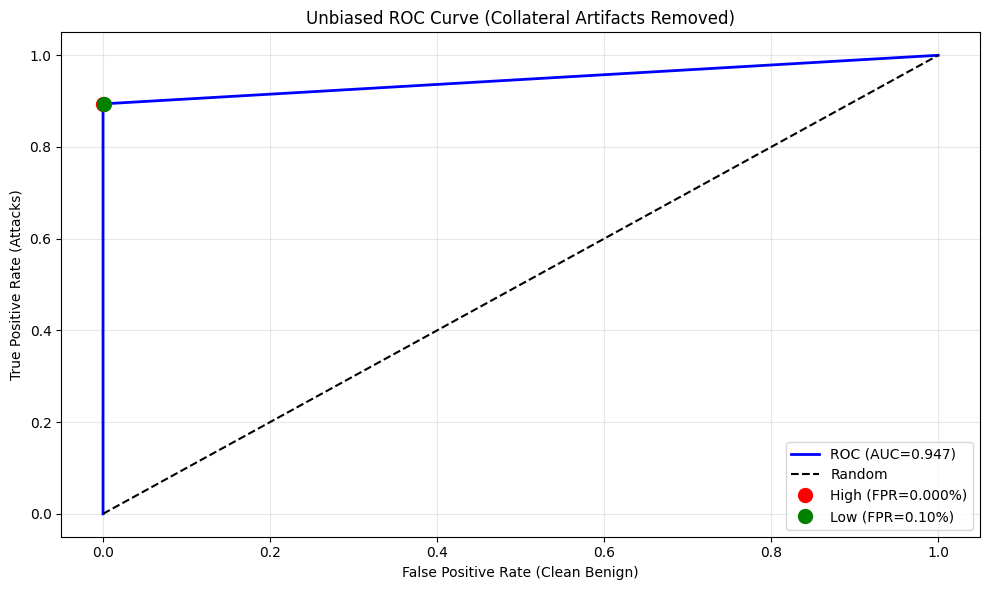


✓ Thresholds calculated and saved!
   Low threshold: 1.00
   High threshold: 10.00

PHASE 2: EVALUATION ON UNSEEN TEST DATA

Found 87 test files

[TEST 1/87] Processing: dump6-fabr-044h.parquet
   Loaded: 4,280,937 messages
   [DEBUG] Total Attacks: 1,028
   [DEBUG] Clean Benign:  4,278,889
   [DEBUG] Dirty Benign:  956 (Excluded from FPR)
   [DEBUG] -> Collateral Anomalies found: 956
   Unbiased Metrics: TPR=100.00%, FPR=0.0000%, F1=1.0000

[TEST 2/87] Processing: dump6-fabr-080h.parquet
   Loaded: 4,375,918 messages
   [DEBUG] Total Attacks: 96,009
   [DEBUG] Clean Benign:  4,190,895
   [DEBUG] Dirty Benign:  88,950 (Excluded from FPR)
   [DEBUG] -> Collateral Anomalies found: 43,974
   Unbiased Metrics: TPR=53.45%, FPR=0.0000%, F1=0.6967

[TEST 3/87] Processing: dump6-fabr-081h.parquet
   Loaded: 4,375,918 messages
   [DEBUG] Total Attacks: 96,009
   [DEBUG] Clean Benign:  4,190,895
   [DEBUG] Dirty Benign:  88,950 (Excluded from FPR)
   [DEBUG] -> Collateral Anomalies found: 44,30

In [ ]:

if __name__ == "__main__":
    
    files_pathname = r"C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategyV2\New_strategy\X-CANIDS"

    train_folder = os.path.join(files_pathname, "thresholds_train")
    
    # Get ALL attack files in the threshold folder
    attack_files = [f for f in os.listdir(train_folder ) 
                    if f.startswith("dump6-") and f.endswith(".parquet")]
    
    print(f"\nFound {len(attack_files)} files for threshold analysis:")
    for f in attack_files[:5]:  # Show first 5
        print(f"   {f}")
    if len(attack_files) > 5:
        print(f"   ... and {len(attack_files)-5} more")
    
    # Build ranges (only once)
    ranges = build_hamming_range_model(
        "artifacts/benign_hamming.csv",
        "artifacts/hamming_ranges_universal.csv"
    )

    print("ranges created")
    ranges_df = pd.read_csv("artifacts/hamming_ranges_universal.csv")
    # ========================================================================
    ranges_indexed = ranges_df.set_index('arbitration_id')
    #results_summary = []
    all_detections = []
    #i made this dict to speed up the lookup of ranges instead of querying the dataframe each time cause it took 4h per file 
    ranges_lookup = {
    row['arbitration_id']: (row['min_hamming'], row['max_hamming'])
    for _, row in ranges_df.iterrows()
}
    
    for i, filename in enumerate(attack_files, 1):  
        print(f"\n[TRAIN {i}/{len(attack_files)}] Processing: {filename}") 
        #just to know at which row i am rn
        #j = 0
        try:
            # Load attack file
            attack_file_path = os.path.join(train_folder, filename)
            attack_df = pq.read_table(attack_file_path).to_pandas()
            
            print(f"   Loaded: {len(attack_df):,} messages")
            prev_payload = {}
            attack_dump = attack_df.copy()
            
            #populating the prev_payload with the benign data at the start _ASK PROFESSOR IF WISE TO DO THAT
            """print("   Seeding baseline...")
            dump6_sorted = dump6.sort_values("timestamp")
            for _, row in dump6_sorted.iterrows():
                _, _, prev_payload = compute_hamming_distances_testing(row, prev_payload)
            
            print(f"   Baseline seeded: {len(prev_payload)} IDs")"""
            
            #-----------------------------------
            
            
            if "timestamp" not in attack_dump.columns:
                if attack_dump.index.name == "timestamp":
                   attack_dump = attack_dump.reset_index()
                else:
                    attack_dump = attack_dump.reset_index().rename(columns={"index": "timestamp"})
                    
            attack_dump = attack_dump.sort_values("timestamp", kind="mergesort")
            
            detect_list = []
            #prev_payload= {}
            # Compute Hamming
            for row in attack_dump.itertuples():
                
                #debugging progress
                """if idx % 10000 == 0:
                    print(f"\r   Processing packets... {idx:,}/{len(attack_df):,}", end="", flush=True)"""
                
                #now here it should return just the distance and the label
                current_aid = row.arbitration_id
                attack_ham_dist, lab, prev_payload = compute_hamming_distances_testing(
                    row, 
                    prev_payload,
                    ranges_indexed # Pass current state
                )
            
                # Detect
                if attack_ham_dist is not None:
                    results = detect_simple(
                        attack_ham_dist,
                        current_aid,
                        lab,  
                        ranges_lookup
                    )
                    #Save Timestamp for sorting later if needed
                    results['timestamp'] = row.timestamp
                    detect_list.append(results)
                    
                 # Compute metrics for this attack file
            # Convert to DataFrame and add to collection
            detections_df = pd.DataFrame(detect_list)
            detections_df['source_file'] = filename  # Track which file
            print(f"\nCalculating anomaly scores for file {i}/21")
            processed_df = prepare_roc_data_efficient(detections_df, ranges_df)
            all_detections.append(processed_df)
            
            print(f"   ✓ Processed {len(processed_df):,} packets")
        
        except Exception as e:
            print(f"   ❌ Error: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    
    print("\n" + "="*70)
    print("PHASE 1: THRESHOLD CALCULATION FROM TRAINING DATA")
    print("="*70)

    # Calculate statistics from training data
    total_train_packets = 0
    total_train_attacks = 0
    total_train_normal = 0
    train_by_type = {'fuzz': 0, 'masq': 0, 'fabr': 0}

    for df in all_detections:
        total_train_packets += len(df)
        total_train_attacks += (df['label'] == 1).sum()
        total_train_normal += (df['label'] == 0).sum()
        
        source = df['source_file'].iloc[0]
        if 'fuzz' in source:
            train_by_type['fuzz'] += len(df)
        elif 'masq' in source:
            train_by_type['masq'] += len(df)
        elif 'fabr' in source:
            train_by_type['fabr'] += len(df)

    print(f"\nTraining set composition:")
    print(f"  Total packets: {total_train_packets:,}")
    print(f"  Attacks: {total_train_attacks:,} ({total_train_attacks/total_train_packets*100:.1f}%)")
    print(f"  Normal: {total_train_normal:,} ({total_train_normal/total_train_packets*100:.1f}%)")

    print(f"\nBy attack type:")
    for atype, count in train_by_type.items():
        if count > 0:
            print(f"   {atype.capitalize()}: {count:,} packets")

    # Combine all training detections
    print(f"\nCombining {len(all_detections)} training files...")
    combined_train = pd.concat(all_detections, ignore_index=True)
    combined_train = combined_train.drop(columns=['source_file'])

    print(f"✓ Combined {len(combined_train):,} training samples")

    # Calculate anomaly scores
    #print("\nCalculating anomaly scores...")
    #df_train_scores = prepare_roc_data_efficient(combined_train, ranges_df)

    # Find optimal thresholds
    print("\nFinding optimal thresholds...")
    thresholds = find_optimal_thresholds(
        combined_train,
        target_fpr_low=0.001,   # 0.11% FPR for low confidence
        target_fpr_high=0.0001   # 0.01% FPR for high confidence
    )

    # Save threshold configuration
    threshold_config = pd.DataFrame([{
        'threshold_low': thresholds['threshold_low'],
        'threshold_high': thresholds['threshold_high'],
        'tpr_low': thresholds['tpr_low'],
        'fpr_low': thresholds['fpr_low'],
        'tpr_high': thresholds['tpr_high'],
        'fpr_high': thresholds['fpr_high'],
        'auc': thresholds['auc'],
        'training_samples': len(combined_train),
        'training_attacks': total_train_attacks
    }])
    threshold_config.to_csv("artifacts/threshold_config.csv", index=False)

    print(f"\n✓ Thresholds calculated and saved!")
    print(f"   Low threshold: {thresholds['threshold_low']:.2f}")
    print(f"   High threshold: {thresholds['threshold_high']:.2f}")

    # ========================================================================
    # PHASE 2: EVALUATION ON TEST SET
    # ========================================================================
    print("\n" + "="*70)
    print("PHASE 2: EVALUATION ON UNSEEN TEST DATA")
    print("="*70)
    
    global_benign_max_score = 0
    global_benign_score_counts = pd.Series(dtype=int)
    total_benign_packets_seen = 0

    test_folder = os.path.join(files_pathname, "thresholds_test")
    test_files = [f for f in os.listdir(test_folder) 
                if f.startswith("dump6-") and f.endswith(".parquet")]

    print(f"\nFound {len(test_files)} test files")
    
    thesis_metrics = {
        'tp': 0, 
        'fn': 0, 
        'tn': 0, 
        'fp_pure': 0,      # The number you want to minimize
        'collateral': 0    # The number you explain away in text
    }

    # Track metrics incrementally
    total_test_packets = 0
    total_test_attacks = 0
    total_test_normal = 0
    test_by_type = {'fuzz': 0, 'masq': 0, 'fabr': 0}

    # Metrics accumulators
    total_tp = 0
    total_tp_high = 0 
    total_tp_low = 0  
    total_fp = 0
    total_tn = 0
    total_fn = 0
    
    type_metrics = {
    'fuzz': {'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0},
    'masq': {'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0},
    'fabr': {'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0}
}

    # Process files one at a time
    for i, filename in enumerate(test_files, 1):
        print(f"\n[TEST {i}/{len(test_files)}] Processing: {filename}")
        
        try:
            # Load file
            test_file_path = os.path.join(test_folder, filename)
            test_df = pq.read_table(test_file_path).to_pandas()
            
            print(f"   Loaded: {len(test_df):,} messages")
            
            # Detection
            prev_payload = {}
            test_dump = test_df.copy()
            
            if "timestamp" not in test_dump.columns:
                if test_dump.index.name == "timestamp":
                    test_dump = test_dump.reset_index()
                else:
                    test_dump = test_dump.reset_index().rename(columns={"index": "timestamp"})
            
            test_dump = test_dump.sort_values("timestamp", kind="mergesort")
            
            detect_list = []
            suspicious_packets_buffer = [] # Simulating the Second System Buffer
            
            for row in test_dump.itertuples():
                current_aid = row.arbitration_id
                test_ham_dist, lab, prev_payload = compute_hamming_distances_testing(
                    row, 
                    prev_payload,
                    ranges_indexed
                )
                
                if test_ham_dist is not None:
                    results = detect_simple(
                        test_ham_dist,
                        current_aid,
                        lab,  
                        ranges_lookup
                    )
                    results['timestamp'] = row.timestamp
                    detect_list.append(results)
                
            # Convert to DataFrame
            detections_df = pd.DataFrame(detect_list)
               
            # Calculate metrics using the function
            df_scores, file_metrics = compute_metrics_from_detections(
                detections_df, 
                ranges_df, 
                thresholds
            )

            # Now 'suspicious_packets' contains ONLY the ones you need to send to the 2nd system
            #print(f"Passing {len(suspicious_packets_buffer)} packets to Second System...")
            
            benign_subset = df_scores[df_scores['label'] == 0]['anomaly_score']
            
            if not benign_subset.empty:
                # 2. Update Max Score
                file_max = benign_subset.max()
                if file_max > global_benign_max_score:
                    global_benign_max_score = file_max
                
                # 3. Update Counts (Histogram) - Keeps track of distribution without keeping rows
                # We only keep the top values to save memory if there are many unique scores
                file_counts = benign_subset.value_counts()
                global_benign_score_counts = global_benign_score_counts.add(file_counts, fill_value=0)
                
                total_benign_packets_seen += len(benign_subset)
            # ==============================

            # Accumulate effective metrics
            total_tp += file_metrics['TP']
            total_tp_high += file_metrics['TP_High'] # <--- NEW
            total_tp_low += file_metrics['TP_Low']   # <--- NEW
            total_fp += file_metrics['FP']
            total_tn += file_metrics['TN']
            total_fn += file_metrics['FN']

            # Update statistics
            total_test_packets += len(df_scores)
            total_test_attacks += (df_scores['label'] == 1).sum()
            total_test_normal += (df_scores['label'] == 0).sum()

            # Track per-type metrics (use effective)
            atype = None
            if 'fuzz' in filename:
                atype = 'fuzz'
                test_by_type['fuzz'] += len(df_scores)
            elif 'masq' in filename:
                atype = 'masq'
                test_by_type['masq'] += len(df_scores)
            elif 'fabr' in filename:
                atype = 'fabr'
                test_by_type['fabr'] += len(df_scores)

            if atype:
                type_metrics[atype]['tp'] += file_metrics['TP']
                type_metrics[atype]['fp'] += file_metrics['FP']
                type_metrics[atype]['tn'] += file_metrics['TN']
                type_metrics[atype]['fn'] += file_metrics['FN']
                
            
            
        except Exception as e:
            print(f"Error: {e}")
            continue

    # ========================================================================
    # TEST SET RESULTS
    # ========================================================================
    print("\n" + "="*70)
    print("TEST SET COMPOSITION")
    print("="*70)
    print(f"  Total packets: {total_test_packets:,}")
    print(f"  Attacks: {total_test_attacks:,} ({total_test_attacks/total_test_packets*100:.1f}%)")
    print(f"  Normal: {total_test_normal:,} ({total_test_normal/total_test_packets*100:.1f}%)")

    print(f"\nBy attack type:")
    for atype, count in test_by_type.items():
        if count > 0:
            print(f"   {atype.capitalize()}: {count:,} packets")

    # Calculate final metrics
    test_tpr = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    test_fpr = total_fp / (total_fp + total_tn) if (total_fp + total_tn) > 0 else 0

    print("\n" + "="*70)
    print("TEST SET PERFORMANCE")
    print("="*70)
    print(f"  TPR: {test_tpr*100:.2f}%")
    print(f"  FPR: {test_fpr*100:.4f}%")
    print(f"  TP: {total_tp:,} | FP: {total_fp:,} | TN: {total_tn:,} | FN: {total_fn:,}")
    
    
    
    # ========================================================================
    # BREAKDOWN BY ATTACK TYPE
    # ========================================================================
    print("\n" + "="*70)
    print("PERFORMANCE BY ATTACK TYPE (using universal threshold)")
    print("="*70)

    for atype, metrics in type_metrics.items():
        if metrics['tp'] + metrics['fn'] > 0:  # Only if we tested this type
            tpr = metrics['tp'] / (metrics['tp'] + metrics['fn'])
            fpr = metrics['fp'] / (metrics['fp'] + metrics['tn']) if (metrics['fp'] + metrics['tn']) > 0 else 0
            
            # Calculate F1
            precision = metrics['tp'] / (metrics['tp'] + metrics['fp']) if (metrics['tp'] + metrics['fp']) > 0 else 0
            recall = tpr
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
            print(f"\n{atype.upper()}:")
            print(f"   TPR: {tpr*100:.2f}%")
            print(f"   FPR: {fpr*100:.4f}%")
            print(f"   Precision: {precision*100:.2f}%")
            print(f"   F1 Score: {f1:.4f}")
            print(f"   TP: {metrics['tp']:,} | FP: {metrics['fp']:,} | TN: {metrics['tn']:,} | FN: {metrics['fn']:,}")

    # ========================================================================
    # FINAL SUMMARY
    # ========================================================================
    print("\n" + "="*70)
    print("FINAL RESULTS SUMMARY")
    print("="*70)
    
    test_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    test_f1 = 2 * (test_precision * test_tpr) / (test_precision + test_tpr) if (test_precision + test_tpr) > 0 else 0   

    print("\n>>> TRAINING SET (used for threshold calculation):")
    print(f"    Files: {len(all_detections)}")
    print(f"    Packets: {total_train_packets:,}")
    print(f"    Thresholds: Low={thresholds['threshold_low']:.2f}, High={thresholds['threshold_high']:.2f}")

    print("\n>>> TEST SET (unseen data - TRUE PERFORMANCE):")
    print(f"    Files: {len(test_files)}")
    print(f"    Packets: {total_test_packets:,}")
    print(f"    TPR: {test_tpr*100:.2f}%")
    print(f"    FPR: {test_fpr*100:.4f}%")
    print(f"    Precision: {test_precision*100:.2f}%")
    print(f"    F1 Score: {test_f1:.4f}")
    print(f"    TP: {total_tp:,} | FP: {total_fp:,} | TN: {total_tn:,} | FN: {total_fn:,}")

    print("\n" + "="*70)
    print("✓ ANALYSIS COMPLETE - READY FOR THESIS!")
    print("="*70)
    
    # ========================================================================
    # FINAL DIAGNOSIS REPORT
    # ========================================================================
    
    print("\n" + "="*70)
    print("DIAGNOSIS RESULTS")
    print("="*70)
    print(f"Total Benign Packets Checked: {total_benign_packets_seen:,}")
    print(f"Max Anomaly Score Observed in Benign: {global_benign_max_score}")
    print(f"Your Low Threshold is: {thresholds['threshold_low']}")
    
    if global_benign_max_score < thresholds['threshold_low']:
        print("\n>>> CONCLUSION: PERFECT BASELINE (OVERFITTING)")
        print("Your benign traffic NEVER exceeds the learned ranges enough to trigger the threshold.")
        print(f"Highest score was {global_benign_max_score}, but you need {thresholds['threshold_low']} to flag as suspicious.")
    else:
        print("\n>>> CONCLUSION: SOMETHING ELSE")
        print("Some packets DID exceed the threshold.")
    
    print("\nScore Distribution (Top 10 scores):")
    # Show the most frequent scores (likely 0 will be huge) and the highest scores
    print(global_benign_score_counts.sort_index(ascending=False).head(10))
    
    
    
    # ========================================================================
    # THESIS VALUE PROPOSITION: TIERED DETECTION ANALYSIS
    # ========================================================================
    print("\n" + "="*70)
    print("VALUE OF THE SECONDARY SYSTEM (TIERED TPR ANALYSIS)")
    print("="*70)
    
    if total_test_attacks > 0:
        tpr_high = total_tp_high / total_test_attacks
        tpr_low_exclusive = total_tp_low / total_test_attacks
        tpr_total = (total_tp_high + total_tp_low) / total_test_attacks
        
        print(f"Total Attacks Tested: {total_test_attacks:,}")
        print(f"Thresholds Used: Low={thresholds['threshold_low']:.2f}, High={thresholds['threshold_high']:.2f}")
        
        print(f"\n{'-'*75}")
        print(f"{'Metric':<25} | {'Count':<12} | {'TPR Contribution':<15} | {'Meaning'}")
        print(f"{'-'*75}")
        
        print(f"{'High Confidence':<25} | {total_tp_high:<12,} | {tpr_high*100:6.2f}%          | Detected & Alerted Immediately")
        print(f"{'Low Confidence':<25} | {total_tp_low:<12,} | {tpr_low_exclusive*100:6.2f}%          | Forwarded to 2nd System")
        print(f"{'Missed (FN)':<25} | {total_fn:<12,} | {(total_fn/total_test_attacks)*100:6.2f}%          | True Stealth (In-Range)")
        print(f"{'-'*75}")
        print(f"{'TOTAL SYSTEM':<25} | {total_tp:<12,} | {tpr_total*100:6.2f}%          | Combined Performance")
        print(f"{'-'*75}")
        
        print("\n>>> THESIS CONCLUSION:")
        print(f"The Secondary System is responsible for catching {tpr_low_exclusive*100:.2f}% of all attacks.")
        print(f"Without the two-stage architecture, these {total_tp_low:,} attacks would have been missed")
        print("or required a high-noise threshold that floods the driver with alerts.")
        